In [1]:
# !pip install pandas scikit-learn matplotlib seaborn numpy xgboost lightgbm

  Using cached pandas-2.3.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.7.2-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.7-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.3.5-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached xgboost-3.1.2-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached scipy-1.16.3-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using ca


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# import libraries
import pandas as pd

print("Library imported successfully")

Library imported successfully


In [4]:
# load dataset
path = "clean_data.csv"
df = pd.read_csv(path)

df

,Planned_Cost,Actual_Cost,Cost_Overrun,Planned_Duration,Actual_Duration,Schedule_Deviation,Vibration_Level,Crack_Width,Load_Bearing_Capacity,Temperature,...,Project_Type_Road,Project_Type_Tunnel,Season_Spring,Season_Summer,Season_Winter,Risk_Category_Encoded,Weather_Condition_Rainy,Weather_Condition_Snowy,Weather_Condition_Stormy,Weather_Condition_Sunny
0,12260784,1.505450e+07,2.793720e+06,699,813.914852,114.914852,1.534172,2.809385,471.197381,18.541555,...,False,True,False,False,True,2,False,True,False,False
1,2369277,3.507054e+06,1.137777e+06,269,384.118221,115.118221,0.687979,3.704416,355.155126,23.316772,...,False,False,False,False,True,0,False,True,False,False
2,23299783,2.169213e+07,-1.607656e+06,899,1081.777915,182.777915,0.951146,3.309302,236.493416,42.957877,...,False,False,False,False,True,1,False,False,False,False
3,24499306,2.946966e+07,4.970354e+06,809,974.565655,165.565655,0.870396,1.777649,360.290394,22.420894,...,False,False,False,False,True,2,False,False,False,False
4,1749971,2.329338e+06,5.793670e+05,354,347.990127,-6.009873,1.969770,4.044293,204.790836,15.914491,...,False,False,False,False,True,0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3570115,4.125885e+06,5.557696e+05,415,534.336045,119.336045,0.238199,4.189207,134.626355,35.956389,...,True,False,False,False,False,2,True,False,False,False
996,8499066,1.189375e+07,3.394681e+06,513,533.380201,20.380201,1.601250,0.361786,242.608709,43.196726,...,False,False,False,False,False,2,False,False,False,True
997,5672412,7.847154e+06,2.174742e+06,528,524.861704,-3.138296,0.513784,4.405526,346.227703,14.126046,...,False,False,False,False,False,2,False,False,False,False
998,20877714,2.159990e+07,7.221838e+05,277,362.885969,85.885969,1.386372,1.283308,168.712734,11.634406,...,False,True,False,False,False,0,False,True,False,False


In [5]:
# preparing data for modeling 
y = df['Risk_Category_Encoded']
X = df.drop(columns=['Risk_Category_Encoded']) 
print(y)
print("=================================================================================")
print(X)

0      2
1      0
2      1
3      2
4      0
      ..
995    2
996    2
997    2
998    0
999    1
Name: Risk_Category_Encoded, Length: 1000, dtype: int64
     Planned_Cost   Actual_Cost  Cost_Overrun  Planned_Duration  \
0        12260784  1.505450e+07  2.793720e+06               699   
1         2369277  3.507054e+06  1.137777e+06               269   
2        23299783  2.169213e+07 -1.607656e+06               899   
3        24499306  2.946966e+07  4.970354e+06               809   
4         1749971  2.329338e+06  5.793670e+05               354   
..            ...           ...           ...               ...   
995       3570115  4.125885e+06  5.557696e+05               415   
996       8499066  1.189375e+07  3.394681e+06               513   
997       5672412  7.847154e+06  2.174742e+06               528   
998      20877714  2.159990e+07  7.221838e+05               277   
999      14177733  1.468313e+07  5.053999e+05               261   

     Actual_Duration  Schedule_Deviation

Training set size: 700 samples
Testing set size: 300 samples
Prediction Accuracy on Test Set: 0.92


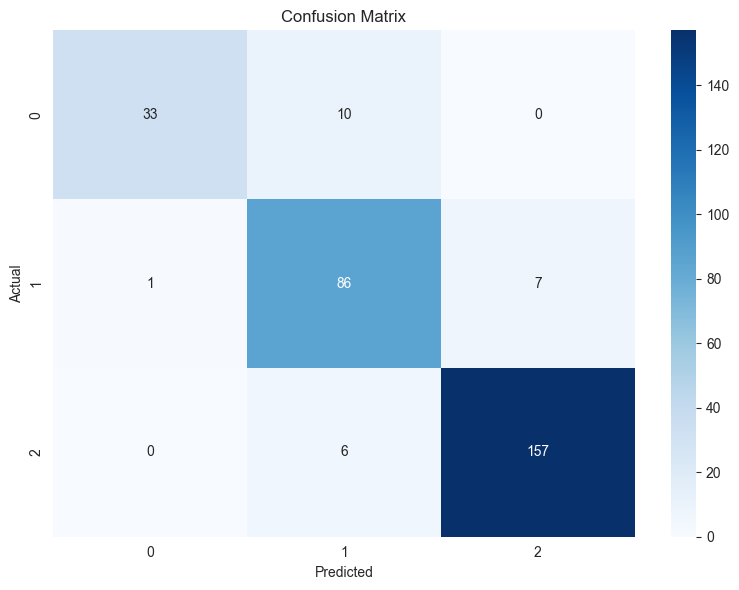

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

# Create a RandomForest classifier and fit the model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = clf.predict(X_test)

# Calculate the prediction accuracy score
accuracy = accuracy_score(y_test, y_pred)
print('Prediction Accuracy on Test Set:', accuracy)

# Generate and visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [7]:
# Fine-tunning 
from sklearn.model_selection import GridSearchCV


# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

# Grid search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.927142857142857


In [8]:
# Future Engineering
import numpy as np

# Avoid divide-by-zero errors
df['Energy_Intensity'] = df['Energy_Consumption'] / (df['Actual_Duration'] + 1e-5)

df['Schedule_Variance'] = (df['Planned_Duration'] - df['Actual_Duration']) / (df['Planned_Duration'] + 1e-5)

df['Cost_Overrun_Ratio'] = df['Actual_Cost'] / (df['Planned_Cost'] + 1e-5)

# Example combined engineered feature
df['Risk_Indicator'] = (
    0.4 * df['Cost_Overrun_Ratio'] +
    0.3 * df['Schedule_Variance'] +
    0.3 * df['Energy_Intensity']
)

# Separate X and y again after adding features
X = df.drop(columns=['Risk_Category_Encoded'])
y = df['Risk_Category_Encoded']


In [9]:
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        learning_rate=0.1,
        max_depth=6,
        n_estimators=300
    ),
    "LightGBM": LGBMClassifier(
        learning_rate=0.05,
        num_leaves=31,
        n_estimators=300
    ),
    "SVM": SVC(kernel='rbf', probability=True)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

print("\nModel Comparison:", results)

RandomForest Accuracy: 0.9167
XGBoost Accuracy: 0.9533
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6796
[LightGBM] [Info] Number of data points in the train set: 700, number of used features: 47
[LightGBM] [Info] Start training from score -1.823693
[LightGBM] [Info] Start training from score -1.037652
[LightGBM] [Info] Start training from score -0.725080
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po